In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("retail_sales_dataset.csv")

In [3]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [5]:
df.shape

(1000, 9)

In [6]:
quality_report = pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Values': df.isnull().sum(),
    'Unique Values': df.nunique()
})

quality_report

,Data Type,Missing Values,Unique Values
Transaction ID,int64,0,1000
Date,str,0,345
Customer ID,str,0,1000
Gender,str,0,2
Age,int64,0,47
Product Category,str,0,3
Quantity,int64,0,4
Price per Unit,int64,0,5
Total Amount,int64,0,18


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


## Missing Value Handling

The dataset was checked for missing values using `isnull().sum()`.

All columns contain 0 missing values. Therefore, no missing-value imputation
or row removal was required.

The original dataset was retained without modification for missing-value handling.

In [9]:
df.isnull().sum().sum()

np.int64(0)

In [10]:
df.duplicated().sum()

np.int64(0)

## Duplicate Record Handling

Duplicate records were identified using `duplicated().sum()`.

The dataset contains 0 duplicate rows. Therefore, no records were removed
during duplicate handling.

df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

df.columns

In [12]:
df['gender'] = df['gender'].str.title()

In [13]:
df['product_category'] = df['product_category'].str.title()

In [14]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    1000 non-null   int64         
 1   date              1000 non-null   datetime64[us]
 2   customer_id       1000 non-null   str           
 3   gender            1000 non-null   str           
 4   age               1000 non-null   int64         
 5   product_category  1000 non-null   str           
 6   quantity          1000 non-null   int64         
 7   price_per_unit    1000 non-null   int64         
 8   total_amount      1000 non-null   int64         
dtypes: datetime64[us](1), int64(5), str(3)
memory usage: 70.4 KB


In [16]:
print("Gender:", df['gender'].unique())
print("Product Categories:", df['product_category'].unique())

Gender: <StringArray>
['Male', 'Female']
Length: 2, dtype: str
Product Categories: <StringArray>
['Beauty', 'Clothing', 'Electronics']
Length: 3, dtype: str


In [ ]:
## Data Standardization

Column names were standardized using lowercase letters and underscores.
Leading and trailing spaces were removed from text fields.

Gender and product category values were standardized to a consistent format.
The Date column was converted to datetime format to ensure correct date-based
processing.

After standardization, the dataset contains consistent column names, text
values, and appropriate data types.

In [20]:
numeric_columns = ['age', 'quantity', 'price_per_unit', 'total_amount']

outlier_report = {}

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    outlier_report[col] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': len(outliers)
    }

outlier_report = pd.DataFrame(outlier_report).T

outlier_report

,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
age,29.0,53.0,24.0,-7.0,89.0,0.0
quantity,1.0,4.0,3.0,-3.5,8.5,0.0
price_per_unit,30.0,300.0,270.0,-375.0,705.0,0.0
total_amount,60.0,900.0,840.0,-1200.0,2160.0,0.0


In [24]:
import matplotlib.pyplot as plt

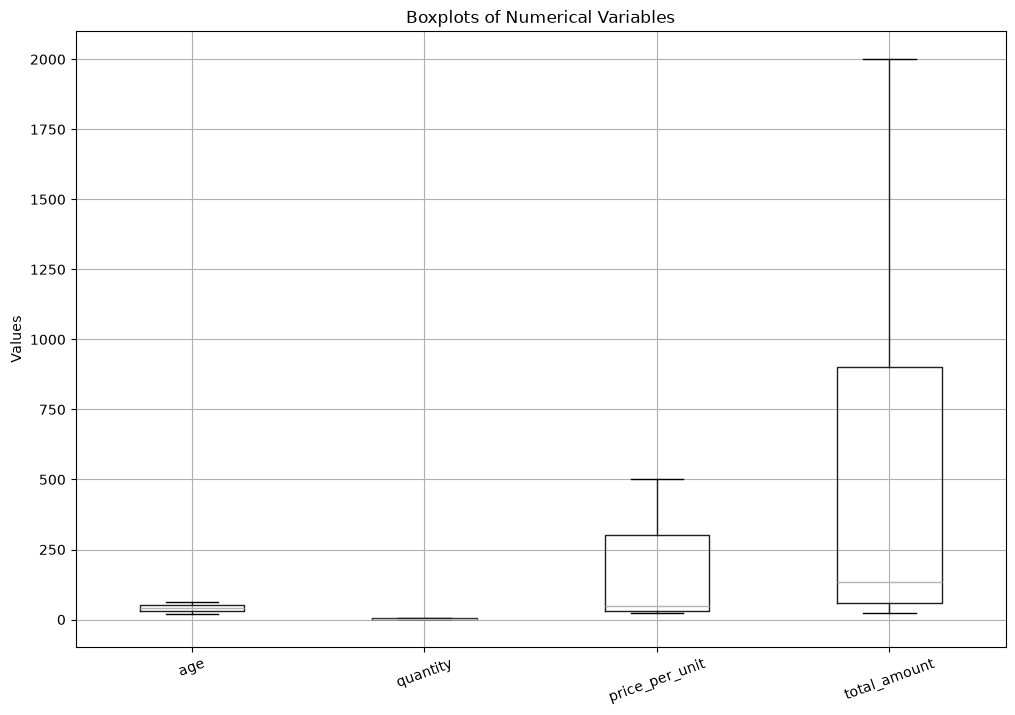

In [25]:
plt.figure(figsize=(12, 8))

df[numeric_columns].boxplot()

plt.title('Boxplots of Numerical Variables')
plt.ylabel('Values')
plt.xticks(rotation=20)

plt.show()

In [26]:
outlier_report

,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
age,29.0,53.0,24.0,-7.0,89.0,0.0
quantity,1.0,4.0,3.0,-3.5,8.5,0.0
price_per_unit,30.0,300.0,270.0,-375.0,705.0,0.0
total_amount,60.0,900.0,840.0,-1200.0,2160.0,0.0


## Outlier Handling

Potential outliers were checked using the Interquartile Range (IQR) method
and visualized using boxplots.

The IQR analysis detected 0 outliers in Age, Quantity, Price per Unit, and
Total Amount.

Therefore, no records were removed or modified due to outliers.

In [27]:
outlier_report


,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
age,29.0,53.0,24.0,-7.0,89.0,0.0
quantity,1.0,4.0,3.0,-3.5,8.5,0.0
price_per_unit,30.0,300.0,270.0,-375.0,705.0,0.0
total_amount,60.0,900.0,840.0,-1200.0,2160.0,0.0


In [28]:
before_rows = 1000
before_columns = 9

after_rows = df.shape[0]
after_columns = df.shape[1]

comparison = pd.DataFrame({
    'Metric': ['Rows', 'Columns', 'Missing Values', 'Duplicate Rows'],
    'Before Cleaning': [
        before_rows,
        before_columns,
        0,
        0
    ],
    'After Cleaning': [
        after_rows,
        after_columns,
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ]
})

comparison

,Metric,Before Cleaning,After Cleaning
0,Rows,1000,1000
1,Columns,9,9
2,Missing Values,0,0
3,Duplicate Rows,0,0


In [29]:
df.to_csv('cleaned_retail_sales_dataset.csv', index=False)

In [30]:
import os
os.listdir()

['.ipynb_checkpoints',
 'cleaned_retail_sales_dataset.csv',
 'data_cleaning.ipynb',
 'retail_sales_dataset.csv']

## Conclusion

The retail sales dataset was systematically inspected and cleaned.

The dataset was checked for missing values, duplicate records, inconsistent
data, incorrect data types, and potential outliers.

No missing values or duplicate records were found. Column names were
standardized, categorical values were cleaned, and the Date column was
converted to datetime format.

The IQR method was used to detect outliers. No outliers were detected in the
selected numerical variables, so no records were removed.

The cleaned dataset was saved as `cleaned_retail_sales_dataset.csv` and is
ready for further analysis.